In [1]:
import sys
import random
import datetime
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    TensorBoard,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


def encontrar_raiz_proyecto(inicio: Path) -> Path:
    inicio = inicio.resolve()

    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "regularizacion").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la carpeta regularizacion."
    )


PROJECT_ROOT = encontrar_raiz_proyecto(Path.cwd())
REG_DIR = PROJECT_ROOT / "regularizacion"

DATA_V3_DIR = REG_DIR / "data" / "v3"

X_PATH = DATA_V3_DIR / "X_combined.npy"
Y_PATH = DATA_V3_DIR / "Y_combined.npy"
SPLITS_PATH = DATA_V3_DIR / "split_indices.npz"
METADATA_PATH = DATA_V3_DIR / "metadata_combined.csv"

MODELS_DIR = REG_DIR / "models" / "v3"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"
FINAL_DIR = MODELS_DIR / "final"

OUTPUTS_DIR = REG_DIR / "outputs" / "v3"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TENSORBOARD_DIR = OUTPUTS_DIR / "tensorboard"

for carpeta in [
    CHECKPOINTS_DIR,
    FINAL_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    TENSORBOARD_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Dataset oficial:", DATA_V3_DIR)
print("Checkpoints:", CHECKPOINTS_DIR)
print("TensorBoard:", TENSORBOARD_DIR)

Dataset oficial: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v3
Checkpoints: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints
TensorBoard: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\outputs\v3\tensorboard


In [2]:
X = np.load(
    X_PATH,
    mmap_mode="r"
)

y_enteras = np.load(
    Y_PATH
).astype(np.int32)

metadata = pd.read_csv(
    METADATA_PATH
)

splits = np.load(
    SPLITS_PATH
)

indices_train = splits["train"]
indices_val = splits["validation"]
indices_test = splits["test"]

X_train = np.asarray(
    X[indices_train],
    dtype=np.float32
)

X_val = np.asarray(
    X[indices_val],
    dtype=np.float32
)

X_test = np.asarray(
    X[indices_test],
    dtype=np.float32
)

y_train_enteras = y_enteras[indices_train]
y_val_enteras = y_enteras[indices_val]
y_test_enteras = y_enteras[indices_test]

origen_train = metadata.iloc[
    indices_train
]["Origen"].to_numpy()

origen_val = metadata.iloc[
    indices_val
]["Origen"].to_numpy()

origen_test = metadata.iloc[
    indices_test
]["Origen"].to_numpy()

y_train = to_categorical(
    y_train_enteras,
    num_classes=10
).astype(np.float32)

y_val = to_categorical(
    y_val_enteras,
    num_classes=10
).astype(np.float32)

y_test = to_categorical(
    y_test_enteras,
    num_classes=10
).astype(np.float32)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)

print()
print(
    "Origen entrenamiento:",
    pd.Series(origen_train).value_counts().to_dict()
)

print(
    "Origen validación:",
    pd.Series(origen_val).value_counts().to_dict()
)

print(
    "Origen prueba:",
    pd.Series(origen_test).value_counts().to_dict()
)

Entrenamiento: (5328, 64, 64, 1) (5328, 10)
Validación: (666, 64, 64, 1) (666, 10)
Prueba: (666, 64, 64, 1) (666, 10)

Origen entrenamiento: {'v2': 3677, 'v1': 1651}
Origen validación: {'v2': 461, 'v1': 205}
Origen prueba: {'v2': 460, 'v1': 206}


In [3]:
assert X_train.shape == (5328, 64, 64, 1)
assert X_val.shape == (666, 64, 64, 1)
assert X_test.shape == (666, 64, 64, 1)

assert y_train.shape == (5328, 10)
assert y_val.shape == (666, 10)
assert y_test.shape == (666, 10)

assert X_train.dtype == np.float32
assert y_train.dtype == np.float32

assert X_train.min() >= 0.0
assert X_train.max() <= 1.0

assert set(np.unique(origen_train)) == {"v1", "v2"}
assert set(np.unique(origen_val)) == {"v1", "v2"}
assert set(np.unique(origen_test)) == {"v1", "v2"}

print("Comprobaciones del dataset v3 superadas.")

Comprobaciones del dataset v3 superadas.


In [4]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Semilla:", SEED)
print("Batch size:", BATCH_SIZE)
print("Épocas máximas:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Semilla: 42
Batch size: 32
Épocas máximas: 100
Learning rate: 0.001


In [5]:
def crear_generador_entrenamiento(seed=SEED):
    generador = ImageDataGenerator(
        rotation_range=12,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.08,
        horizontal_flip=False,
        fill_mode="nearest",
    )

    return generador.flow(
        X_train,
        y_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=seed,
    )


generador_prueba = crear_generador_entrenamiento()

lote_x, lote_y = next(generador_prueba)

print("Forma del lote:", lote_x.shape)
print("Forma de etiquetas:", lote_y.shape)
print("Rango del lote:", lote_x.min(), "a", lote_x.max())

Forma del lote: (32, 64, 64, 1)
Forma de etiquetas: (32, 10)
Rango del lote: 0.0 a 0.9903779


Primer entrenamiento: Modelo A base

In [6]:
def crear_modelo_base(seed=SEED):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    modelo = Sequential(
        [
            Input(
                shape=(64, 64, 1),
                name="Entrada"
            ),

            Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                name="Convolucion_1"
            ),

            MaxPooling2D(
                pool_size=(2, 2),
                name="Pooling_1"
            ),

            Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                name="Convolucion_2"
            ),

            MaxPooling2D(
                pool_size=(2, 2),
                name="Pooling_2"
            ),

            Flatten(
                name="Aplanado"
            ),

            Dense(
                units=64,
                activation="relu",
                name="Densa_64"
            ),

            Dense(
                units=10,
                activation="softmax",
                name="Salida"
            )
        ],
        name="Modelo_A_Base_v3"
    )

    modelo.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


modelo_base = crear_modelo_base()
modelo_base.summary()

Model: "Modelo_A_Base_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolucion_1 (Conv2D)          │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_1 (MaxPooling2D)        │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolucion_2 (Conv2D)          │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_2 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_64 (Dense)                │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,346 (3.14 MB)

 Trainable params: 822,346 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
marca_tiempo = datetime.datetime.now().strftime(
    "%Y%m%d-%H%M%S"
)

ruta_log_base = (
    TENSORBOARD_DIR
    / f"modelo_A_base_{marca_tiempo}"
)

ruta_modelo_base = (
    CHECKPOINTS_DIR
    / "modelo_A_base_mejor.keras"
)

early_stopping_base = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_base = ModelCheckpoint(
    filepath=str(ruta_modelo_base),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

tensorboard_base = TensorBoard(
    log_dir=str(ruta_log_base),
    histogram_freq=0
)

print("TensorBoard:", ruta_log_base)
print("Modelo:", ruta_modelo_base)

TensorBoard: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\outputs\v3\tensorboard\modelo_A_base_20260712-035059
Modelo: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras


In [8]:
inicio_entrenamiento = time.perf_counter()

historial_base = modelo_base.fit(
    crear_generador_entrenamiento(),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping_base,
        checkpoint_base,
        tensorboard_base
    ],
    verbose=2
)

fin_entrenamiento = time.perf_counter()

tiempo_total_base = (
    fin_entrenamiento
    - inicio_entrenamiento
)

epocas_ejecutadas_base = len(
    historial_base.history["loss"]
)

print()
print("TIEMPO DE ENTRENAMIENTO")
print("-" * 45)

print(
    f"Tiempo total: "
    f"{tiempo_total_base / 60:.2f} minutos"
)

print(
    f"Épocas ejecutadas: "
    f"{epocas_ejecutadas_base}"
)

print(
    f"Promedio por época: "
    f"{tiempo_total_base / epocas_ejecutadas_base:.2f} segundos"
)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.53819, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras
167/167 - 5s - 33ms/step - accuracy: 0.4827 - loss: 1.4633 - val_accuracy: 0.8243 - val_loss: 0.5382
Epoch 2/100

Epoch 2: val_loss improved from 0.53819 to 0.30009, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras
167/167 - 4s - 25ms/step - accuracy: 0.7819 - loss: 0.6761 - val_accuracy: 0.9159 - val_loss: 0.3001
Epoch 3/100

Epoch 3: val_loss improved from 0.30009 to 0

In [9]:
modelo_base_mejor = tf.keras.models.load_model(
    ruta_modelo_base
)

print("Mejor modelo base cargado.")
print("Parámetros:", modelo_base_mejor.count_params())

Mejor modelo base cargado.
Parámetros: 822346


In [10]:
val_loss_base, val_accuracy_base = (
    modelo_base_mejor.evaluate(
        X_val,
        y_val,
        verbose=0
    )
)

probabilidades_val_base = modelo_base_mejor(
    X_val,
    training=False
).numpy()

predicciones_val_base = np.argmax(
    probabilidades_val_base,
    axis=1
)

mejor_epoca_base = (
    np.argmin(
        historial_base.history["val_loss"]
    )
    + 1
)

print("MODELO A BASE — VALIDACIÓN")
print("-" * 45)
print("Mejor época:", mejor_epoca_base)
print(f"Accuracy: {val_accuracy_base * 100:.2f}%")
print(f"Loss: {val_loss_base:.6f}")

MODELO A BASE — VALIDACIÓN
---------------------------------------------
Mejor época: 60
Accuracy: 99.25%
Loss: 0.029059


In [11]:
resultados_por_origen = []

for origen in ["v1", "v2"]:
    mascara = origen_val == origen

    y_real_origen = y_val_enteras[mascara]

    probabilidades_origen = (
        probabilidades_val_base[mascara]
    )

    predicciones_origen = np.argmax(
        probabilidades_origen,
        axis=1
    )

    accuracy_origen = np.mean(
        predicciones_origen
        == y_real_origen
    )

    loss_origen = float(
        tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                y_real_origen,
                probabilidades_origen
            )
        ).numpy()
    )

    resultados_por_origen.append({
        "Origen": origen,
        "Cantidad": int(mascara.sum()),
        "Accuracy": accuracy_origen,
        "Accuracy_porcentaje": accuracy_origen * 100,
        "Loss_clasificacion": loss_origen
    })

tabla_origen_base = pd.DataFrame(
    resultados_por_origen
)

tabla_origen_base

,Origen,Cantidad,Accuracy,Accuracy_porcentaje,Loss_clasificacion
0,v1,205,0.980488,98.04878,0.050921
1,v2,461,0.997831,99.78308,0.019338


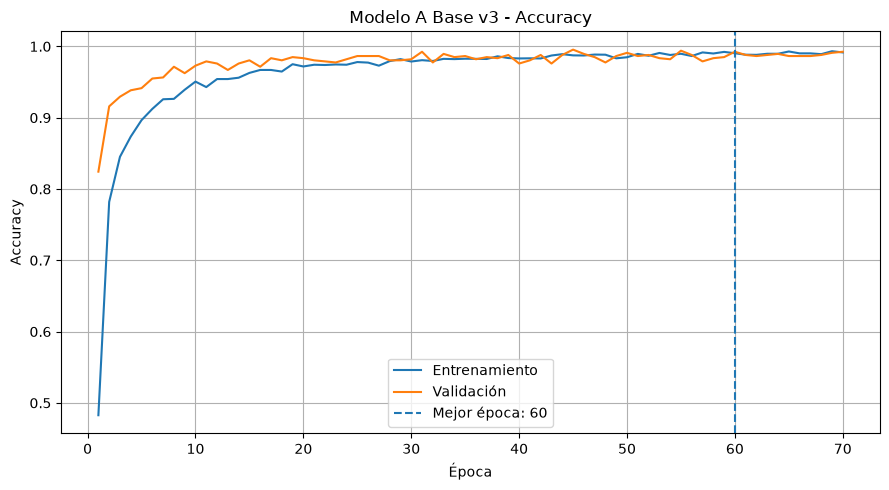

In [12]:
epocas = np.arange(
    1,
    len(historial_base.history["loss"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    historial_base.history["accuracy"],
    label="Entrenamiento"
)

plt.plot(
    epocas,
    historial_base.history["val_accuracy"],
    label="Validación"
)

plt.axvline(
    mejor_epoca_base,
    linestyle="--",
    label=f"Mejor época: {mejor_epoca_base}"
)

plt.title("Modelo A Base v3 - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "modelo_A_base_accuracy.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

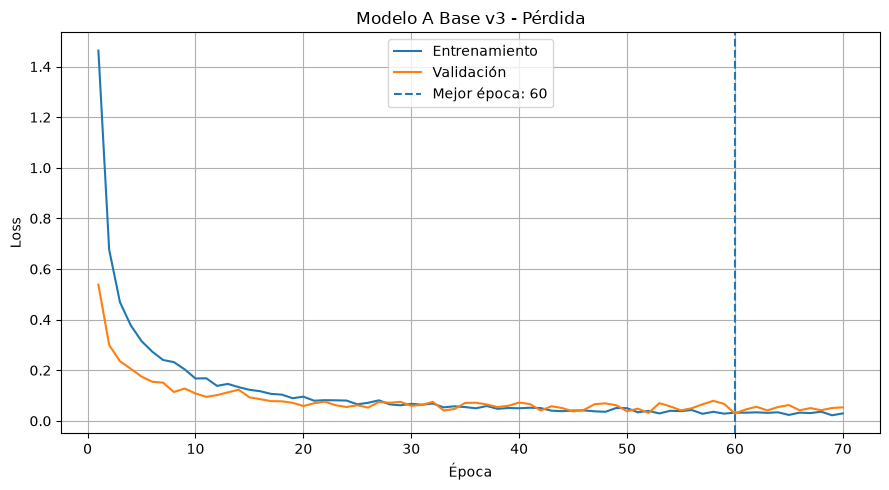

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    historial_base.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    epocas,
    historial_base.history["val_loss"],
    label="Validación"
)

plt.axvline(
    mejor_epoca_base,
    linestyle="--",
    label=f"Mejor época: {mejor_epoca_base}"
)

plt.title("Modelo A Base v3 - Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "modelo_A_base_loss.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [14]:
resultado_base = {
    "Modelo": "A - Base",
    "Parametros": modelo_base_mejor.count_params(),
    "Mejor_epoca": mejor_epoca_base,
    "Epocas_ejecutadas": epocas_ejecutadas_base,
    "Val_accuracy": float(val_accuracy_base),
    "Val_accuracy_porcentaje": float(
        val_accuracy_base * 100
    ),
    "Val_loss": float(val_loss_base),
    "Tiempo_total_minutos": float(
        tiempo_total_base / 60
    ),
    "Segundos_por_epoca": float(
        tiempo_total_base
        / epocas_ejecutadas_base
    ),
    "Ruta_modelo": str(ruta_modelo_base)
}

tabla_resultados = pd.DataFrame(
    [resultado_base]
)

tabla_resultados.to_csv(
    METRICS_DIR / "comparacion_modelos_v3.csv",
    index=False
)

tabla_origen_base.to_csv(
    METRICS_DIR
    / "modelo_A_base_validacion_por_origen.csv",
    index=False
)

tabla_resultados

,Modelo,Parametros,Mejor_epoca,Epocas_ejecutadas,Val_accuracy,Val_accuracy_porcentaje,Val_loss,Tiempo_total_minutos,Segundos_por_epoca,Ruta_modelo
0,A - Base,822346,60,70,0.992492,99.24925,0.029059,4.877885,4.181044,C:\Users\Bastian\Desktop\Universidad\NOVENO SE...


### Resultado del modelo base

El modelo base fue entrenado utilizando el dataset combinado v3 y
aumento de datos aplicado únicamente al conjunto de entrenamiento.

El entrenamiento se ejecutó durante 70 épocas. Early Stopping detuvo el
proceso después de diez épocas consecutivas sin una mejora en la pérdida
de validación y restauró los pesos correspondientes a la época 60.

En su mejor época, el modelo obtuvo una exactitud de validación de
99,25 % y una pérdida de 0,02906. El entrenamiento completo tardó
aproximadamente 4,88 minutos, con un promedio de 4,18 segundos por
época.

La cercanía entre el rendimiento de entrenamiento y validación no
muestra evidencia de sobreajuste grave. Las variaciones posteriores a
la época 60 justifican el uso de Early Stopping para conservarar el
estado con mejor capacidad de generalización.

## Modelo C: regularización L1 con factor 1e-5

Después de entrenar el modelo base, se evaluará la configuración L1 de
1e-5, seleccionada como la alternativa regularizada más estable durante
los experimentos realizados con el dataset anterior.

Para realizar una comparación justa, se conservarán la misma
arquitectura, semilla, tasa de aprendizaje, aumento de datos, división
del dataset y criterio de Early Stopping utilizados en el modelo base.

La regularización L1 será aplicada a la capa densa de 64 neuronas, que
concentra la mayor parte de los parámetros del modelo. Su objetivo es
reducir conexiones poco importantes y disminuir la dependencia de
pesos innecesarios.

In [15]:
L1_FACTOR = 1e-5


def crear_modelo_l1(seed=SEED):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    modelo = Sequential(
        [
            Input(
                shape=(64, 64, 1),
                name="Entrada"
            ),

            Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                name="Convolucion_1"
            ),

            MaxPooling2D(
                pool_size=(2, 2),
                name="Pooling_1"
            ),

            Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                name="Convolucion_2"
            ),

            MaxPooling2D(
                pool_size=(2, 2),
                name="Pooling_2"
            ),

            Flatten(
                name="Aplanado"
            ),

            Dense(
                units=64,
                activation="relu",
                kernel_regularizer=regularizers.l1(
                    L1_FACTOR
                ),
                name="Densa_64_L1"
            ),

            Dense(
                units=10,
                activation="softmax",
                name="Salida"
            )
        ],
        name="Modelo_C_L1_1e5_v3"
    )

    modelo.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


modelo_l1 = crear_modelo_l1()
modelo_l1.summary()

Model: "Modelo_C_L1_1e5_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolucion_1 (Conv2D)          │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_1 (MaxPooling2D)        │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolucion_2 (Conv2D)          │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_2 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_64_L1 (Dense)             │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,346 (3.14 MB)

 Trainable params: 822,346 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
marca_tiempo_l1 = datetime.datetime.now().strftime(
    "%Y%m%d-%H%M%S"
)

ruta_log_l1 = (
    TENSORBOARD_DIR
    / f"modelo_C_L1_1e5_{marca_tiempo_l1}"
)

ruta_modelo_l1 = (
    CHECKPOINTS_DIR
    / "modelo_C_L1_1e5_mejor.keras"
)

early_stopping_l1 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_l1 = ModelCheckpoint(
    filepath=str(ruta_modelo_l1),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

tensorboard_l1 = TensorBoard(
    log_dir=str(ruta_log_l1),
    histogram_freq=0
)

print("TensorBoard:", ruta_log_l1)
print("Modelo:", ruta_modelo_l1)

TensorBoard: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\outputs\v3\tensorboard\modelo_C_L1_1e5_20260712-041207
Modelo: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras


In [17]:
inicio_l1 = time.perf_counter()

historial_l1 = modelo_l1.fit(
    crear_generador_entrenamiento(),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping_l1,
        checkpoint_l1,
        tensorboard_l1
    ],
    verbose=2
)

fin_l1 = time.perf_counter()

tiempo_total_l1 = (
    fin_l1 - inicio_l1
)

epocas_ejecutadas_l1 = len(
    historial_l1.history["loss"]
)

print()
print("TIEMPO MODELO C L1 1e-5")
print("-" * 45)

print(
    f"Tiempo total: "
    f"{tiempo_total_l1 / 60:.2f} minutos"
)

print(
    f"Épocas ejecutadas: "
    f"{epocas_ejecutadas_l1}"
)

print(
    f"Promedio por época: "
    f"{tiempo_total_l1 / epocas_ejecutadas_l1:.2f} segundos"
)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.63127, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras
167/167 - 6s - 36ms/step - accuracy: 0.4722 - loss: 1.5367 - val_accuracy: 0.8228 - val_loss: 0.6313
Epoch 2/100

Epoch 2: val_loss improved from 0.63127 to 0.38302, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras
167/167 - 5s - 27ms/step - accuracy: 0.7798 - loss: 0.7561 - val_accuracy: 0.9114 - val_loss: 0.3830
Epoch 3/100

Epoch 3: val_loss improved from 0.38

In [18]:
modelo_l1_mejor = tf.keras.models.load_model(
    ruta_modelo_l1
)

val_loss_total_l1, val_accuracy_l1 = (
    modelo_l1_mejor.evaluate(
        X_val,
        y_val,
        verbose=0
    )
)

probabilidades_val_l1 = modelo_l1_mejor(
    X_val,
    training=False
).numpy()

val_loss_clasificacion_l1 = float(
    tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(
            y_val,
            probabilidades_val_l1
        )
    ).numpy()
)

penalizacion_l1 = float(
    val_loss_total_l1
    - val_loss_clasificacion_l1
)

mejor_epoca_l1 = (
    np.argmin(
        historial_l1.history["val_loss"]
    )
    + 1
)

print("MODELO C L1 1e-5 — VALIDACIÓN")
print("-" * 50)

print("Mejor época:", mejor_epoca_l1)

print(
    f"Accuracy: "
    f"{val_accuracy_l1 * 100:.2f}%"
)

print(
    f"Pérdida de clasificación: "
    f"{val_loss_clasificacion_l1:.6f}"
)

print(
    f"Penalización L1: "
    f"{penalizacion_l1:.6f}"
)

print(
    f"Pérdida total: "
    f"{val_loss_total_l1:.6f}"
)

MODELO C L1 1e-5 — VALIDACIÓN
--------------------------------------------------
Mejor época: 30
Accuracy: 98.80%
Pérdida de clasificación: 0.037050
Penalización L1: 0.108664
Pérdida total: 0.145714


In [21]:
def evaluar_probabilidades_por_origen(
    probabilidades: np.ndarray,
    etiquetas_enteras: np.ndarray,
    origenes: np.ndarray
) -> pd.DataFrame:
    """
    Calcula accuracy y pérdida de clasificación por dataset de origen.

    Parámetros:
    - probabilidades: salida Softmax del modelo, forma (n, 10).
    - etiquetas_enteras: dígitos reales, forma (n,).
    - origenes: origen de cada imagen, por ejemplo 'v1' o 'v2'.

    Retorna:
    - DataFrame con métricas separadas para v1 y v2.
    """

    resultados = []

    for origen in ["v1", "v2"]:
        # Selecciona solo las imágenes pertenecientes a este origen.
        mascara = origenes == origen

        y_real_origen = etiquetas_enteras[
            mascara
        ]

        probabilidades_origen = probabilidades[
            mascara
        ]

        # La clase predicha es la posición con mayor probabilidad.
        y_predicha_origen = np.argmax(
            probabilidades_origen,
            axis=1
        )

        accuracy_origen = np.mean(
            y_predicha_origen
            == y_real_origen
        )

        # Calcula la pérdida predictiva sin incluir L1.
        loss_clasificacion_origen = float(
            tf.reduce_mean(
                tf.keras.losses
                .sparse_categorical_crossentropy(
                    y_real_origen,
                    probabilidades_origen
                )
            ).numpy()
        )

        resultados.append({
            "Origen": origen,
            "Cantidad": int(
                mascara.sum()
            ),
            "Accuracy": float(
                accuracy_origen
            ),
            "Accuracy_porcentaje": float(
                accuracy_origen * 100
            ),
            "Loss_clasificacion": (
                loss_clasificacion_origen
            )
        })

    return pd.DataFrame(
        resultados
    )

In [22]:
tabla_origen_l1 = (
    evaluar_probabilidades_por_origen(
        probabilidades_val_l1,
        y_val_enteras,
        origen_val
    )
)

tabla_origen_l1

,Origen,Cantidad,Accuracy,Accuracy_porcentaje,Loss_clasificacion
0,v1,205,0.970732,97.073171,0.062127
1,v2,461,0.995662,99.566161,0.025899


El modelo con regularización L1 de factor 1e-5, seleccionado como la mejor configuración regularizada en los experimentos iniciales con el dataset v1, fue reentrenado utilizando el dataset combinado v3. Sin embargo, obtuvo una exactitud de validación de 98,80 %, inferior al 99,25 % alcanzado por el modelo base. Asimismo, presentó una mayor pérdida de clasificación y un rendimiento inferior en ambos datasets de origen. Estos resultados sugieren que el aumento y la diversificación del conjunto de datos, junto con el aumento artificial aplicado durante el entrenamiento, redujeron la necesidad de regularización explícita. Por ello, el modelo base fue seleccionado como la mejor alternativ